<a href="https://colab.research.google.com/github/behraj/journals/blob/main/VP24_shared_copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Transfer Learning Expriment

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# Define the small network architecture
class SmallNetwork(nn.Module):
    def __init__(self):
        super(SmallNetwork, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Define the pre-trained model (a simple identity mapping for demonstration)
class PretrainedModel(nn.Module):
    def __init__(self):
        super(PretrainedModel, self).__init__()

    def forward(self, x):
        return x

# Function to evaluate performance (accuracy for simplicity)
def evaluate_performance(output, labels):
    _, predicted = torch.max(output, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    accuracy = correct / total
    return accuracy

# Function to calculate loss (CrossEntropyLoss for simplicity)
def calculate_loss(output, labels):
    criterion = nn.CrossEntropyLoss()
    loss = criterion(output, labels)
    return loss

# Function to load shifted data (MNIST dataset with a shift in intensity)
def load_shifted_data():
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    shifted_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    # Simulate a shift in intensity
    shifted_dataset.data = shifted_dataset.data * 0.8

    shifted_loader = DataLoader(shifted_dataset, batch_size=64, shuffle=True)
    return shifted_loader

# Initialize Small Network and Pre-trained Model
small_network = SmallNetwork()
pretrained_model = PretrainedModel()

# Define the optimizer for updating small network weights
optimizer = optim.Adam(small_network.parameters(), lr=0.001)

# Function to adapt small network for covariate shift
def adapt_for_covariate_shift(shifted_loader):
    for images, labels in shifted_loader:
        # Pass shifted data through the small network
        output_shifted = small_network(images)

        # Pass shifted data output through pre-trained model and evaluate performance
        with torch.no_grad():
            output_pretrained = pretrained_model(output_shifted)
            performance_shifted = evaluate_performance(output_pretrained, labels)

        # Calculate loss based on the performance
        loss_shifted = calculate_loss(output_shifted, labels)

        # Update small network weights based on the loss
        small_network.zero_grad()
        loss_shifted.backward()
        optimizer.step()

        print(f"Performance on shifted data: {performance_shifted:.2%}, Loss: {loss_shifted.item()}")

# Example usage
shifted_loader = load_shifted_data()

# Adapt small network for covariate shift
adapt_for_covariate_shift(shifted_loader)


100%|██████████| 9912422/9912422 [00:00<00:00, 86759760.95it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 74590944.47it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 27547315.91it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 12362445.66it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Performance on shifted data: 17.19%, Loss: 2.307138681411743
Performance on shifted data: 10.94%, Loss: 2.49141526222229
Performance on shifted data: 12.50%, Loss: 2.2548580169677734
Performance on shifted data: 4.69%, Loss: 2.370398998260498
Performance on shifted data: 7.81%, Loss: 2.3065781593322754
Performance on shifted data: 7.81%, Loss: 2.3434553146362305
Performance on shifted data: 9.38%, Loss: 2.2923424243927
Performance on shifted data: 14.06%, Loss: 2.3017683029174805
Performance on shifted data: 15.62%, Loss: 2.2339093685150146
Performance on shifted data: 17.19%, Loss: 2.267101764678955
Performance on shifted data: 15.62%, Loss: 2.3002512454986572
Performance on shifted data: 18.75%, Loss: 2.2633073329925537
Performance on shifted data: 26.56%, Loss: 2.153064012527466
Performance on shifted data: 14.06%, Loss: 2.321145534515381
Performance on shifted data: 12.50%, Loss: 2.3328983783721924
Performan

## Transfer Learning (idea)

### Custom CNN and ResNet18

In [ ]:
### Data loading
import torch
from torchvision import datasets, transforms

# Define transformations
transform = transforms.Compose([transforms.ToTensor()])

# Load dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 170498071/170498071 [00:13<00:00, 13029094.69it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # First convolutional layer (with pooling)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Second convolutional layer (with pooling)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Third convolutional layer (with pooling)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)  # Adjusted for third convolutional layer output size
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 + ReLU + Pool
        x = self.pool(F.relu(self.conv3(x)))  # Conv3 + ReLU + Pool
        x = x.view(-1, 128 * 4 * 4)           # Flatten the tensor
        x = F.relu(self.fc1(x))               # Fully connected layer 1 + ReLU
        x = self.fc2(x)                       # Fully connected layer 2 (output layer)
        return x


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class CustomResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomResNet18, self).__init__()

        # Load the pre-trained ResNet-18 model
        self.resnet18 = models.resnet18(pretrained=True)

        # Freeze all layers of ResNet-18
        for param in self.resnet18.parameters():
            param.requires_grad = False

        # Remove the final fully connected layer of ResNet-18
        self.resnet18 = nn.Sequential(*list(self.resnet18.children())[:-2])

        # Additional CNN layers
        self.conv1 = nn.Conv2d(in_channels=512, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Ensure the feature map size is maintained
        self.conv4 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=1, padding=0)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # Use Adaptive Pooling to get fixed size

        # Fully connected layers
        self.fc1 = nn.Linear(256, 512)  # Adjusted for the output size after adaptive pooling
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass through ResNet-18
        x = self.resnet18(x)

        # Additional CNN layers
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))

        # Adaptive pooling to ensure a fixed size before flattening
        x = self.pool(x)

        # Flatten the tensor
        x = x.view(x.size(0), -1)  # Flatten while preserving batch size

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the device to use (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming you have defined your models as follows:
# from your_model_module import SimpleCNN, CustomResNet18  # Modify as needed

# Load the custom CNN model (SimpleCNN)
model1 = SimpleCNN(num_classes=10).to(device)

# Load the extended ResNet model with additional CNN layers
model2 = CustomResNet18(num_classes=10).to(device)

# Define loss function (same for both models)
criterion = nn.CrossEntropyLoss()

# Define separate optimizers for each model
optimizer1 = optim.SGD(model1.parameters(), lr=0.001, momentum=0.9)
optimizer2 = optim.SGD(model2.parameters(), lr=0.001, momentum=0.9)

# Assuming you have a DataLoader defined for training data
# train_loader = ...

# Train both models simultaneously
num_epochs = 10
for epoch in range(num_epochs):
    model1.train()
    model2.train()

    for inputs, labels in train_loader:
        # Move data to GPU if available
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients for both models
        optimizer1.zero_grad()
        optimizer2.zero_grad()

        # Forward pass for both models
        outputs1 = model1(inputs)
        outputs2 = model2(inputs)

        # Compute loss for both models
        loss1 = criterion(outputs1, labels)
        loss2 = criterion(outputs2, labels)

        # Backward pass and optimize for both models
        loss1.backward()
        optimizer1.step()

        loss2.backward()
        optimizer2.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss1: {loss1.item():.4f}, Loss2: {loss2.item():.4f}')


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Epoch [1/10], Loss1: 2.2948, Loss2: 2.3009
Epoch [2/10], Loss1: 1.8042, Loss2: 2.3004
Epoch [3/10], Loss1: 2.0297, Loss2: 2.3026
Epoch [4/10], Loss1: 1.7428, Loss2: 2.3023
Epoch [5/10], Loss1: 1.8174, Loss2: 2.3023
Epoch [6/10], Loss1: 1.6265, Loss2: 2.3044
Epoch [7/10], Loss1: 1.6797, Loss2: 2.2906
Epoch [8/10], Loss1: 1.2131, Loss2: 2.3068
Epoch [9/10], Loss1: 1.2151, Loss2: 1.9891
Epoch [10/10], Loss1: 1.1542, Loss2: 2.1670


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def get_softmax_outputs(model, data_loader, device):
    model.eval()
    model.to(device)  # Ensure the model is on the correct device
    softmax_outputs = []
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)  # Move inputs to the correct device
            outputs = model(inputs)

            # Ensure the output is the expected shape (batch_size, num_classes)
            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            softmax_probs = F.softmax(outputs, dim=1)
            softmax_outputs.append(softmax_probs.cpu().numpy())  # Move to CPU before appending

    # Concatenate along the batch axis
    return np.concatenate(softmax_outputs, axis=0)

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
softmax_outputs_model1 = get_softmax_outputs(model1, test_loader, device)
softmax_outputs_model2 = get_softmax_outputs(model2, test_loader, device)


In [ ]:
print(softmax_outputs_model2)

[[1.0023618e-02 3.1246802e-02 9.3508489e-02 ... 1.6674963e-01
  8.8475421e-03 2.5855074e-02]
 [1.6371022e-01 2.2693856e-02 9.8295894e-04 ... 3.9630817e-04
  7.7330238e-01 3.8703110e-02]
 [1.4548294e-01 1.3637218e-01 8.0694616e-02 ... 9.2409857e-02
  1.9363914e-01 1.5235212e-01]
 ...
 [7.8767417e-03 4.6446338e-02 5.3943779e-02 ... 1.4784724e-01
  7.5905370e-03 4.3077510e-02]
 [5.9921961e-02 6.5175943e-02 1.2781319e-01 ... 1.5146481e-01
  5.3992938e-02 6.6144437e-02]
 [4.1913465e-03 1.7939150e-02 6.3346326e-02 ... 1.4209379e-01
  3.1440856e-03 1.5473897e-02]]


Model 1 Softmax Averages: [0.10963499 0.09710176 0.10324449 0.11337871 0.10865135 0.11213313
 0.11529765 0.08167774 0.09336636 0.06551351]
Model 2 Softmax Averages: [0.07858052 0.09498723 0.11182109 0.11480321 0.09114517 0.10764868
 0.11552063 0.10714354 0.08596019 0.09239   ]


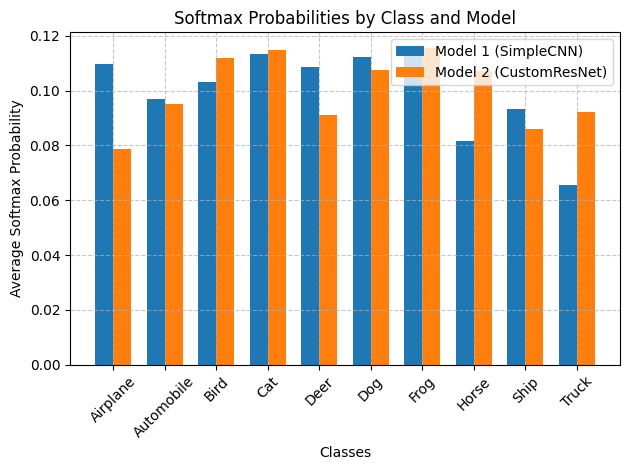

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_softmax_comparison(softmax_outputs_model1, softmax_outputs_model2, class_names):
    # Compute average softmax probabilities for each class
    avg_softmax_model1 = np.mean(softmax_outputs_model1, axis=0)
    avg_softmax_model2 = np.mean(softmax_outputs_model2, axis=0)

    # Debug: Print to check if averages differ
    print("Model 1 Softmax Averages:", avg_softmax_model1)
    print("Model 2 Softmax Averages:", avg_softmax_model2)

    # Set up the plot
    x = np.arange(len(class_names))  # class indices
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots()
    bars1 = ax.bar(x - width/2, avg_softmax_model1, width, label='Model 1 (SimpleCNN)')
    bars2 = ax.bar(x + width/2, avg_softmax_model2, width, label='Model 2 (CustomResNet)')

    # Add some text for labels, title, and custom x-axis tick labels, etc.
    ax.set_xlabel('Classes')
    ax.set_ylabel('Average Softmax Probability')
    ax.set_title('Softmax Probabilities by Class and Model')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.legend()

    # Add a grid for easier visualization
    ax.grid(True, linestyle='--', alpha=0.7)

    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

# CIFAR-10 class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Example usage
visualize_softmax_comparison(softmax_outputs_model1, softmax_outputs_model2, class_names)


In [ ]:
import numpy as np

def compute_entropy(prob_dist):
    return -np.sum(prob_dist * np.log(prob_dist + 1e-9), axis=1)

def compute_max_probability(prob_dist):
    return np.max(prob_dist, axis=1)

# Calculate entropy and max probabilities
entropy_model1 = compute_entropy(softmax_outputs_model1)
entropy_model2 = compute_entropy(softmax_outputs_model2)

max_prob_model1 = compute_max_probability(softmax_outputs_model1)
max_prob_model2 = compute_max_probability(softmax_outputs_model2)

# Compare the means
mean_entropy_model1 = np.mean(entropy_model1)
mean_entropy_model2 = np.mean(entropy_model2)

mean_max_prob_model1 = np.mean(max_prob_model1)
mean_max_prob_model2 = np.mean(max_prob_model2)

print(f"Mean Entropy Before: {mean_entropy_model1}, After: {mean_entropy_model2}")
print(f"Mean Max Probability Before: {mean_max_prob_model1}, After: {mean_max_prob_model2}")


Mean Entropy Before: 1.3824700117111206, After: 1.8724019527435303
Mean Max Probability Before: 0.4972221553325653, After: 0.27429553866386414


Entropy T-test: TtestResult(statistic=-105.58712759124317, pvalue=0.0, df=9999)
Max Probability T-test: TtestResult(statistic=114.48042506441394, pvalue=0.0, df=9999)


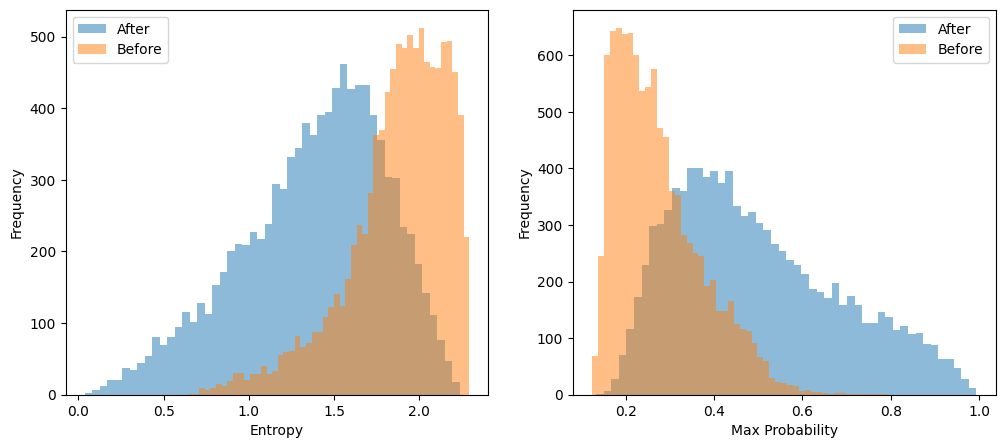

In [ ]:
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# Paired t-test for entropy
ttest_entropy = ttest_rel(entropy_model1, entropy_model2)
print(f"Entropy T-test: {ttest_entropy}")

# Paired t-test for max probability
ttest_max_prob = ttest_rel(max_prob_model1, max_prob_model2)
print(f"Max Probability T-test: {ttest_max_prob}")

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(entropy_model1, bins=50, alpha=0.5, label='After')
plt.hist(entropy_model2, bins=50, alpha=0.5, label='Before')
plt.xlabel('Entropy')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(max_prob_model1, bins=50, alpha=0.5, label='After')
plt.hist(max_prob_model2, bins=50, alpha=0.5, label='Before')
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.legend()

plt.show()


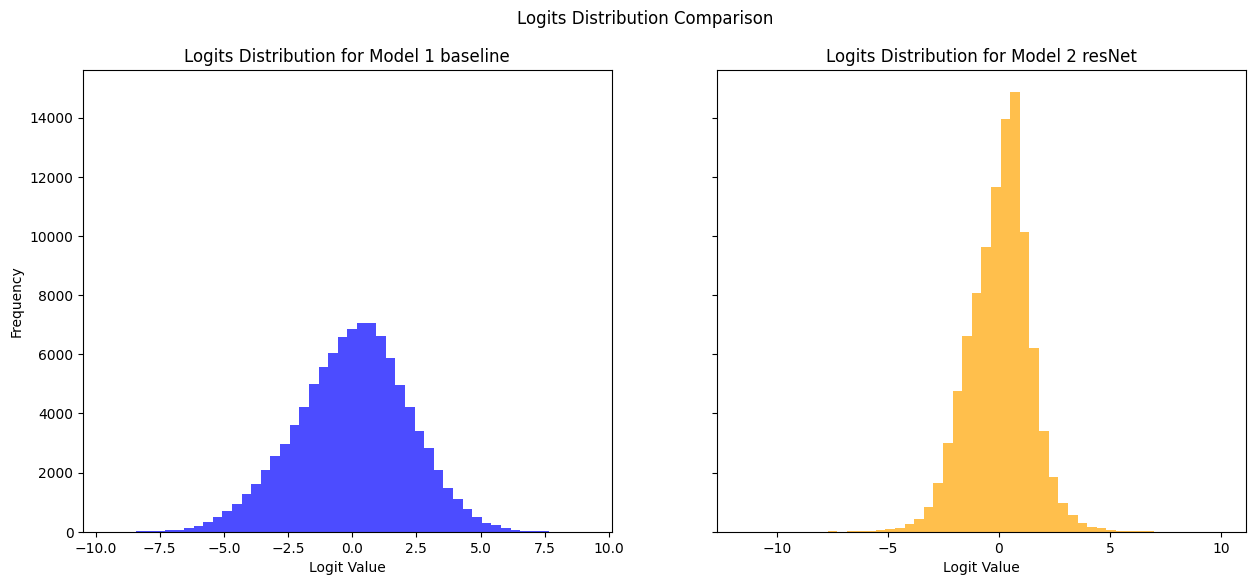

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_logits(model, data_loader, device):
    model.eval()
    model.to(device)
    logits_outputs = []
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            logits_outputs.append(outputs.cpu().numpy())

    return np.concatenate(logits_outputs, axis=0)

def plot_logits_histogram_subplots(logits1, logits2, model_name1, model_name2):
    fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    axs[0].hist(logits1.flatten(), bins=50, alpha=0.7, color='blue')
    axs[0].set_title(f'Logits Distribution for {model_name1}')
    axs[0].set_xlabel('Logit Value')
    axs[0].set_ylabel('Frequency')

    axs[1].hist(logits2.flatten(), bins=50, alpha=0.7, color='orange')
    axs[1].set_title(f'Logits Distribution for {model_name2}')
    axs[1].set_xlabel('Logit Value')

    plt.suptitle('Logits Distribution Comparison')
    plt.show()

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
logits_model1 = get_logits(model1, test_loader, device)
logits_model2 = get_logits(model2, test_loader, device)

# Visualize the logits using subplots
plot_logits_histogram_subplots(logits_model1, logits_model2, "Model 1 baseline", "Model 2 resNet")


#### per example logit

In [ ]:
import torch
import numpy as np

def get_logits_per_example(model, data_loader, device):
    model.eval()
    model.to(device)
    logits_per_example = []
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            # Move logits to CPU and append to the list
            logits_per_example.extend(outputs.cpu().numpy())

    return logits_per_example

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage to get logits for each example in the test set
logits_per_example_model1 = get_logits_per_example(model1, test_loader, device)
logits_per_example_model2 = get_logits_per_example(model2, test_loader, device)

# Each entry in logits_per_example_model1 and logits_per_example_model2 corresponds to a single example's logits


In [ ]:
first_example_logits_model1 = logits_per_example_model1[0]
second_example_logits_model2 = logits_per_example_model2[1]
print("Model 1 baseline logit scores per example ", first_example_logits_model1)
print("Model 2 baseline logit scores per example ",second_example_logits_model2)

Model 1 baseline logit scores per example  [-0.6849449  -0.85214967  1.5743679   2.7579374   0.30284446  1.5937016
  0.81268954 -2.685065   -0.49947074 -2.133016  ]
Model 2 baseline logit scores per example  [ 4.811927    2.8359232  -0.30335927 -2.9123416  -2.759588   -3.2614944
 -5.9390736  -1.2117344   6.364499    3.3697488 ]


#### 5000 logits visualization

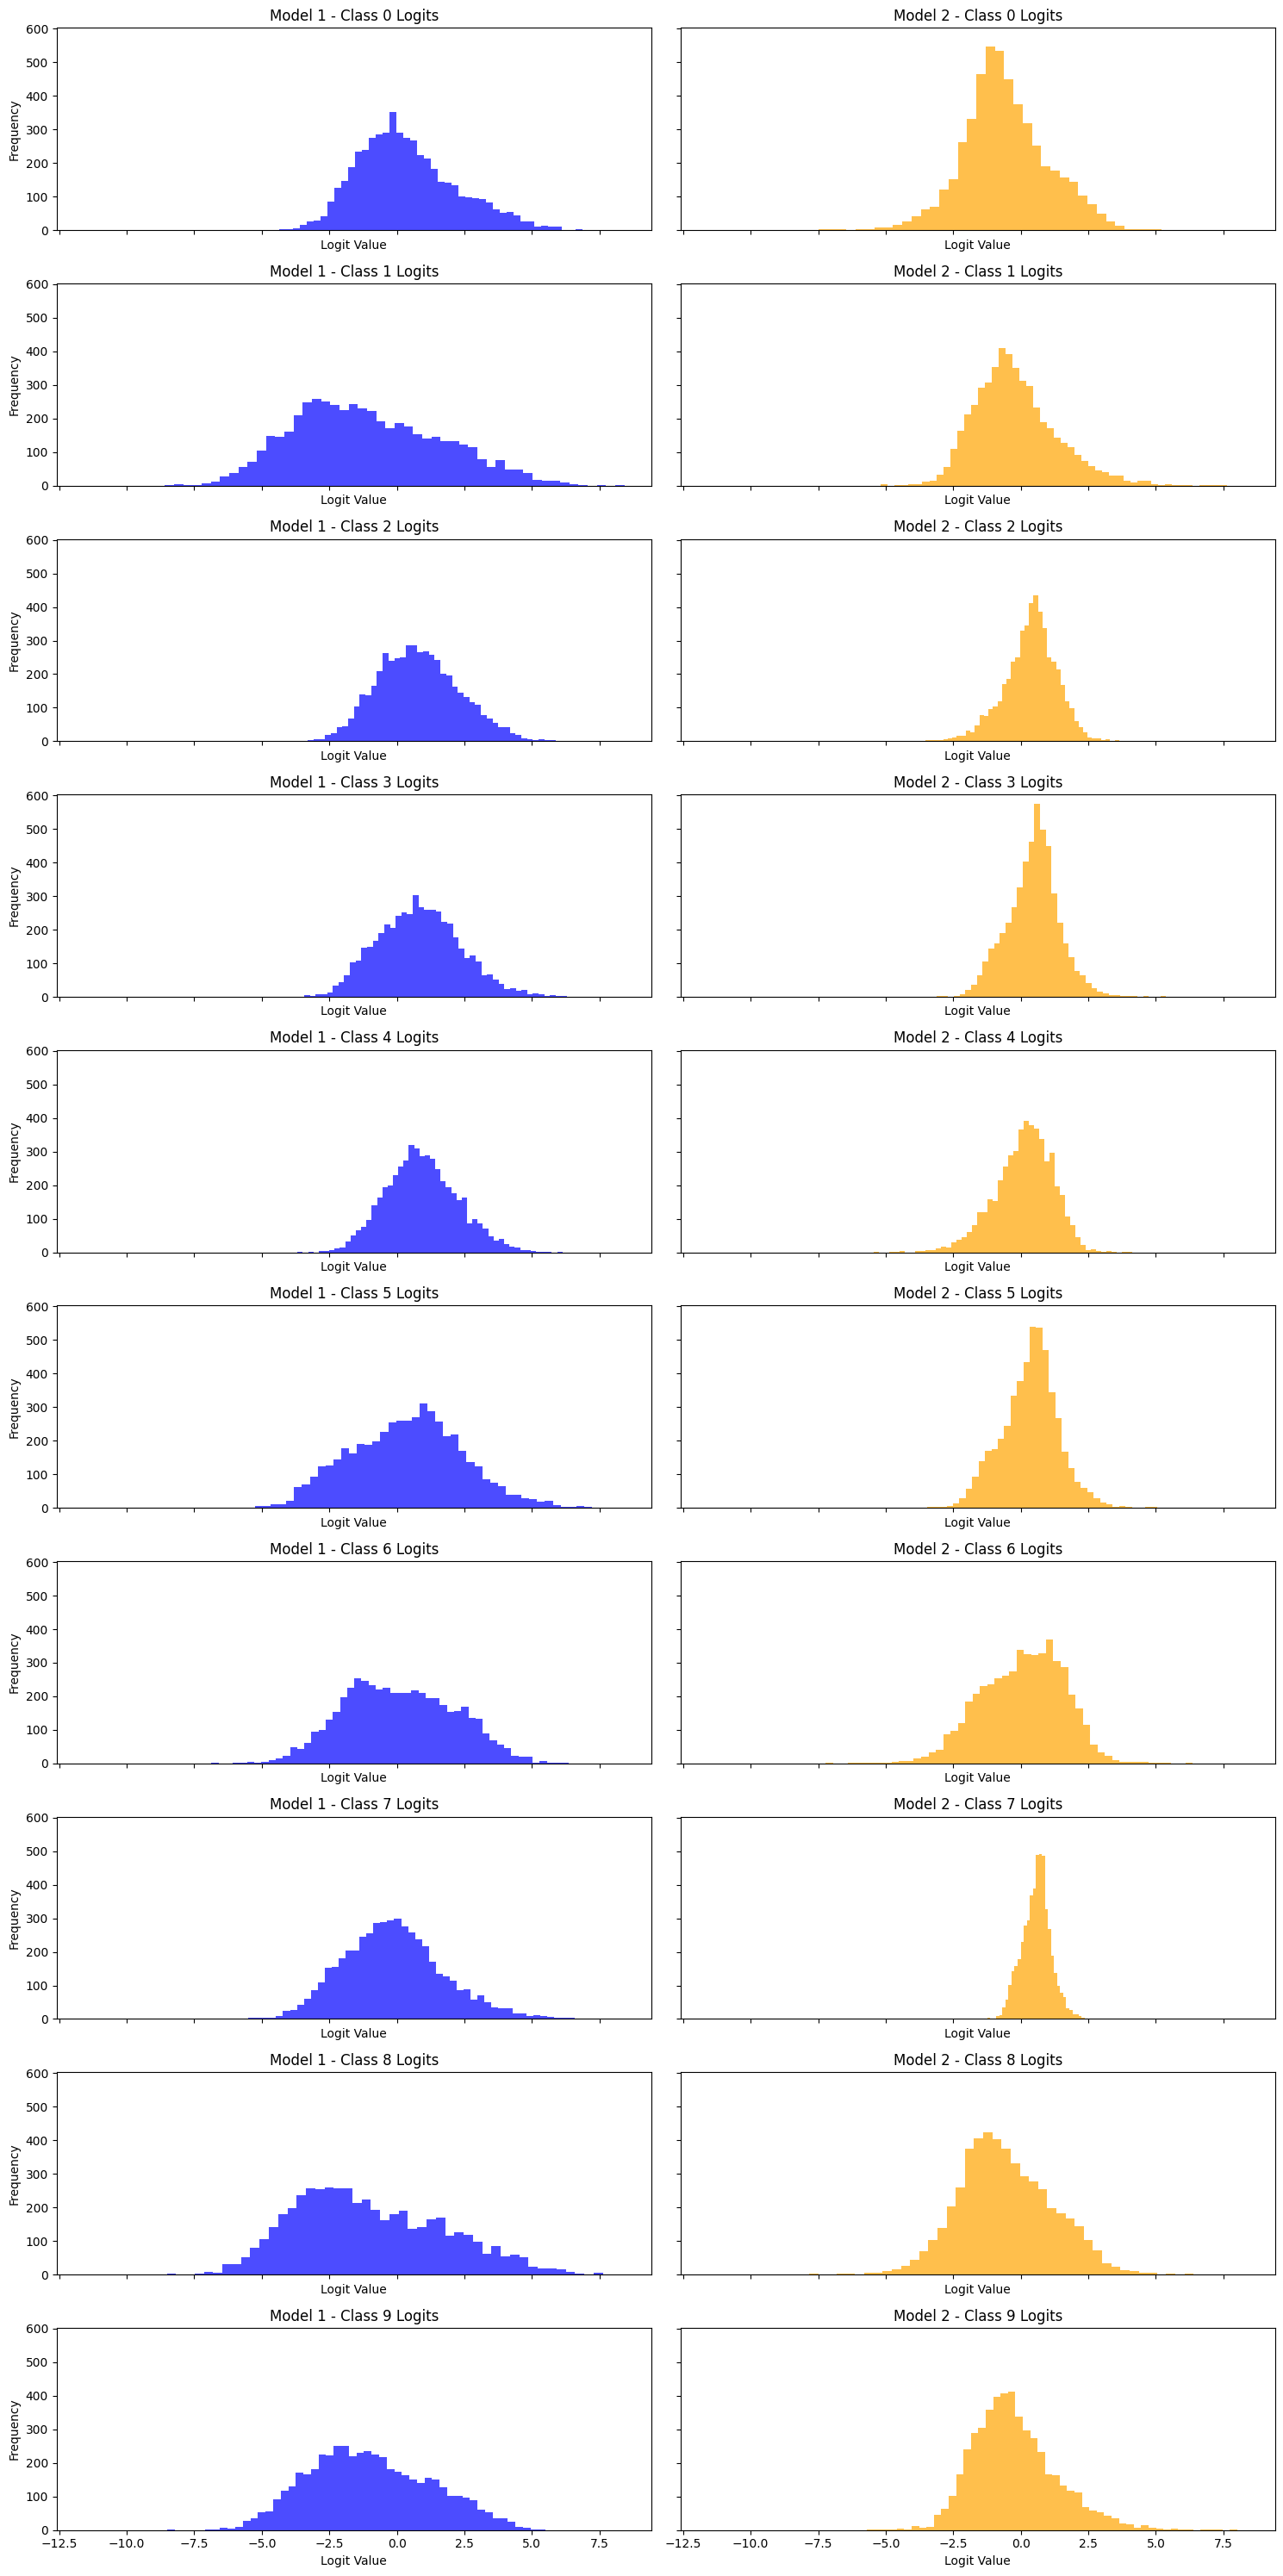

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_logits_for_visualization(model, data_loader, device, max_examples=5000):
    model.eval()
    model.to(device)
    logits_per_example = []
    example_count = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            logits_per_example.extend(outputs.cpu().numpy())
            example_count += inputs.size(0)

            if example_count >= max_examples:
                break

    return np.array(logits_per_example[:max_examples])

def plot_logits_histogram_per_class(logits1, logits2, model_name1, model_name2, num_classes=10, num_bins=50):
    fig, axs = plt.subplots(num_classes, 2, figsize=(15, num_classes * 3), sharex=True, sharey=True)

    for i in range(num_classes):
        axs[i, 0].hist(logits1[:, i], bins=num_bins, alpha=0.7, color='blue')
        axs[i, 0].set_title(f'{model_name1} - Class {i} Logits')
        axs[i, 0].set_ylabel('Frequency')

        axs[i, 1].hist(logits2[:, i], bins=num_bins, alpha=0.7, color='orange')
        axs[i, 1].set_title(f'{model_name2} - Class {i} Logits')

    for ax in axs[:, 0]:
        ax.set_xlabel('Logit Value')
    for ax in axs[:, 1]:
        ax.set_xlabel('Logit Value')

    plt.tight_layout()
    plt.show()

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect logits for visualization (first 5000 examples)
logits_model1 = get_logits_for_visualization(model1, test_loader, device, max_examples=5000)
logits_model2 = get_logits_for_visualization(model2, test_loader, device, max_examples=5000)

# Visualize the logits for each class side by side
plot_logits_histogram_per_class(logits_model1, logits_model2, "Model 1", "Model 2")


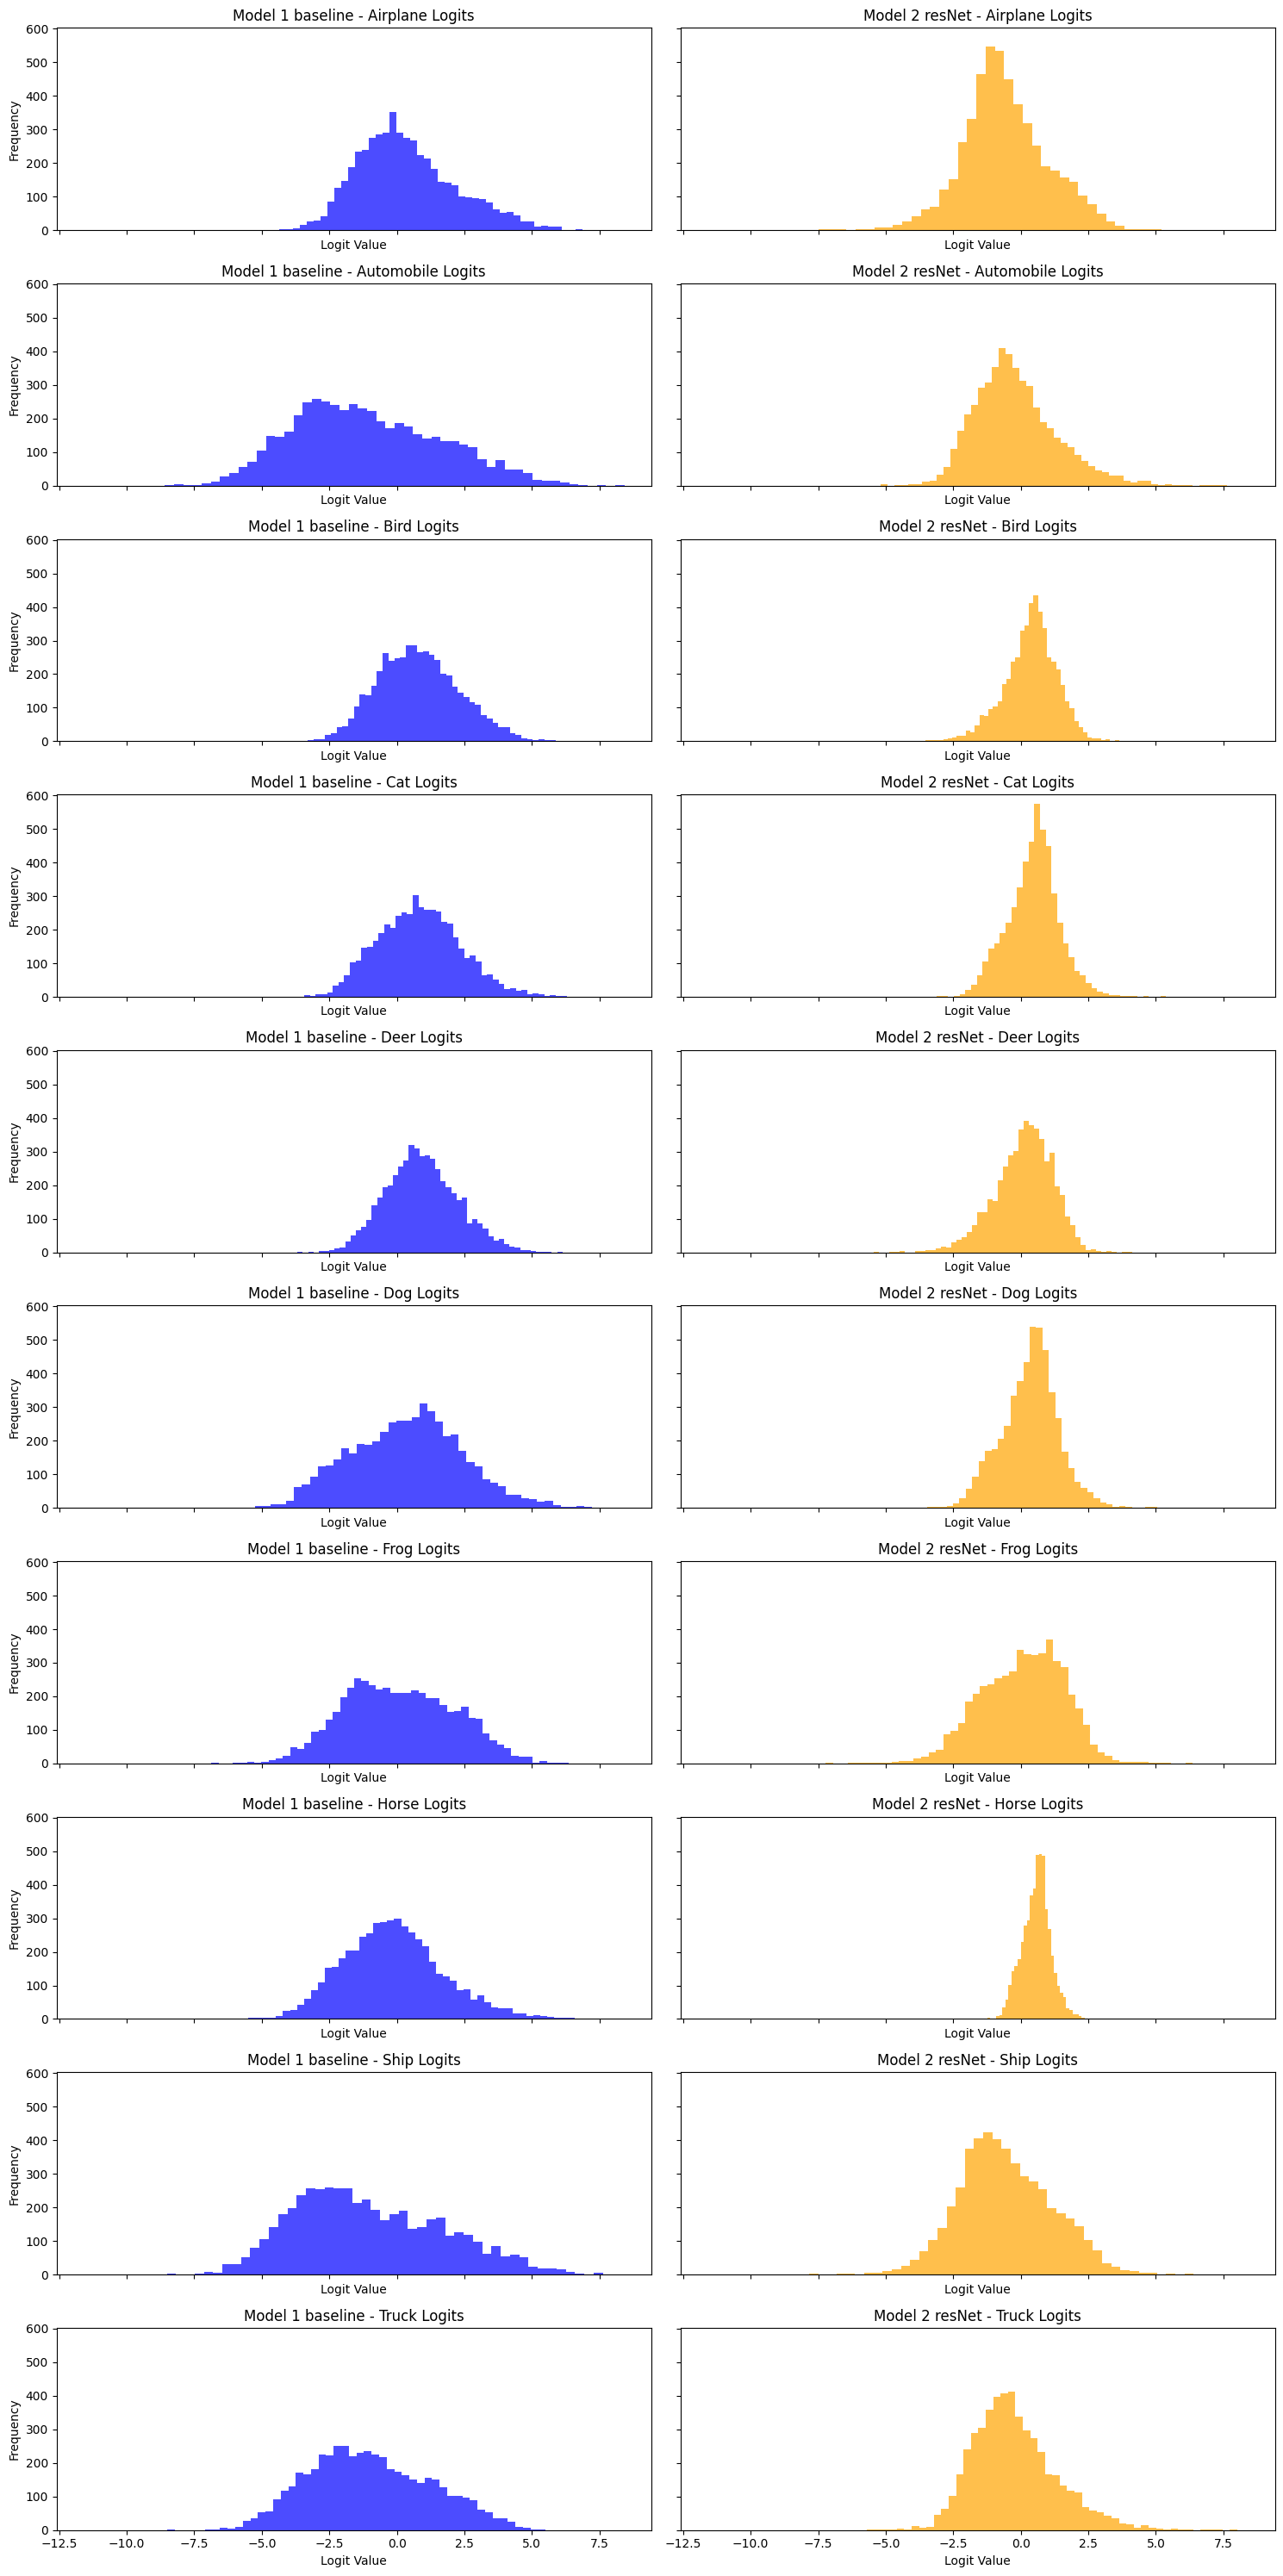

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class labels
cifar10_labels = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

def get_logits_for_visualization(model, data_loader, device, max_examples=5000):
    model.eval()
    model.to(device)
    logits_per_example = []
    example_count = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            logits_per_example.extend(outputs.cpu().numpy())
            example_count += inputs.size(0)

            if example_count >= max_examples:
                break

    return np.array(logits_per_example[:max_examples])

def plot_logits_histogram_per_class(logits1, logits2, model_name1, model_name2, num_classes=10, num_bins=50):
    fig, axs = plt.subplots(num_classes, 2, figsize=(15, num_classes * 3), sharex=True, sharey=True)

    for i in range(num_classes):
        axs[i, 0].hist(logits1[:, i], bins=num_bins, alpha=0.7, color='blue')
        axs[i, 0].set_title(f'{model_name1} - {cifar10_labels[i]} Logits')
        axs[i, 0].set_ylabel('Frequency')

        axs[i, 1].hist(logits2[:, i], bins=num_bins, alpha=0.7, color='orange')
        axs[i, 1].set_title(f'{model_name2} - {cifar10_labels[i]} Logits')

    for ax in axs[:, 0]:
        ax.set_xlabel('Logit Value')
    for ax in axs[:, 1]:
        ax.set_xlabel('Logit Value')

    plt.tight_layout()
    plt.show()

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect logits for visualization (first 5000 examples)
logits_model1 = get_logits_for_visualization(model1, test_loader, device, max_examples=5000)
logits_model2 = get_logits_for_visualization(model2, test_loader, device, max_examples=5000)

# Visualize the logits for each class side by side with CIFAR-10 labels
plot_logits_histogram_per_class(logits_model1, logits_model2, "Model 1 baseline", "Model 2 resNet")


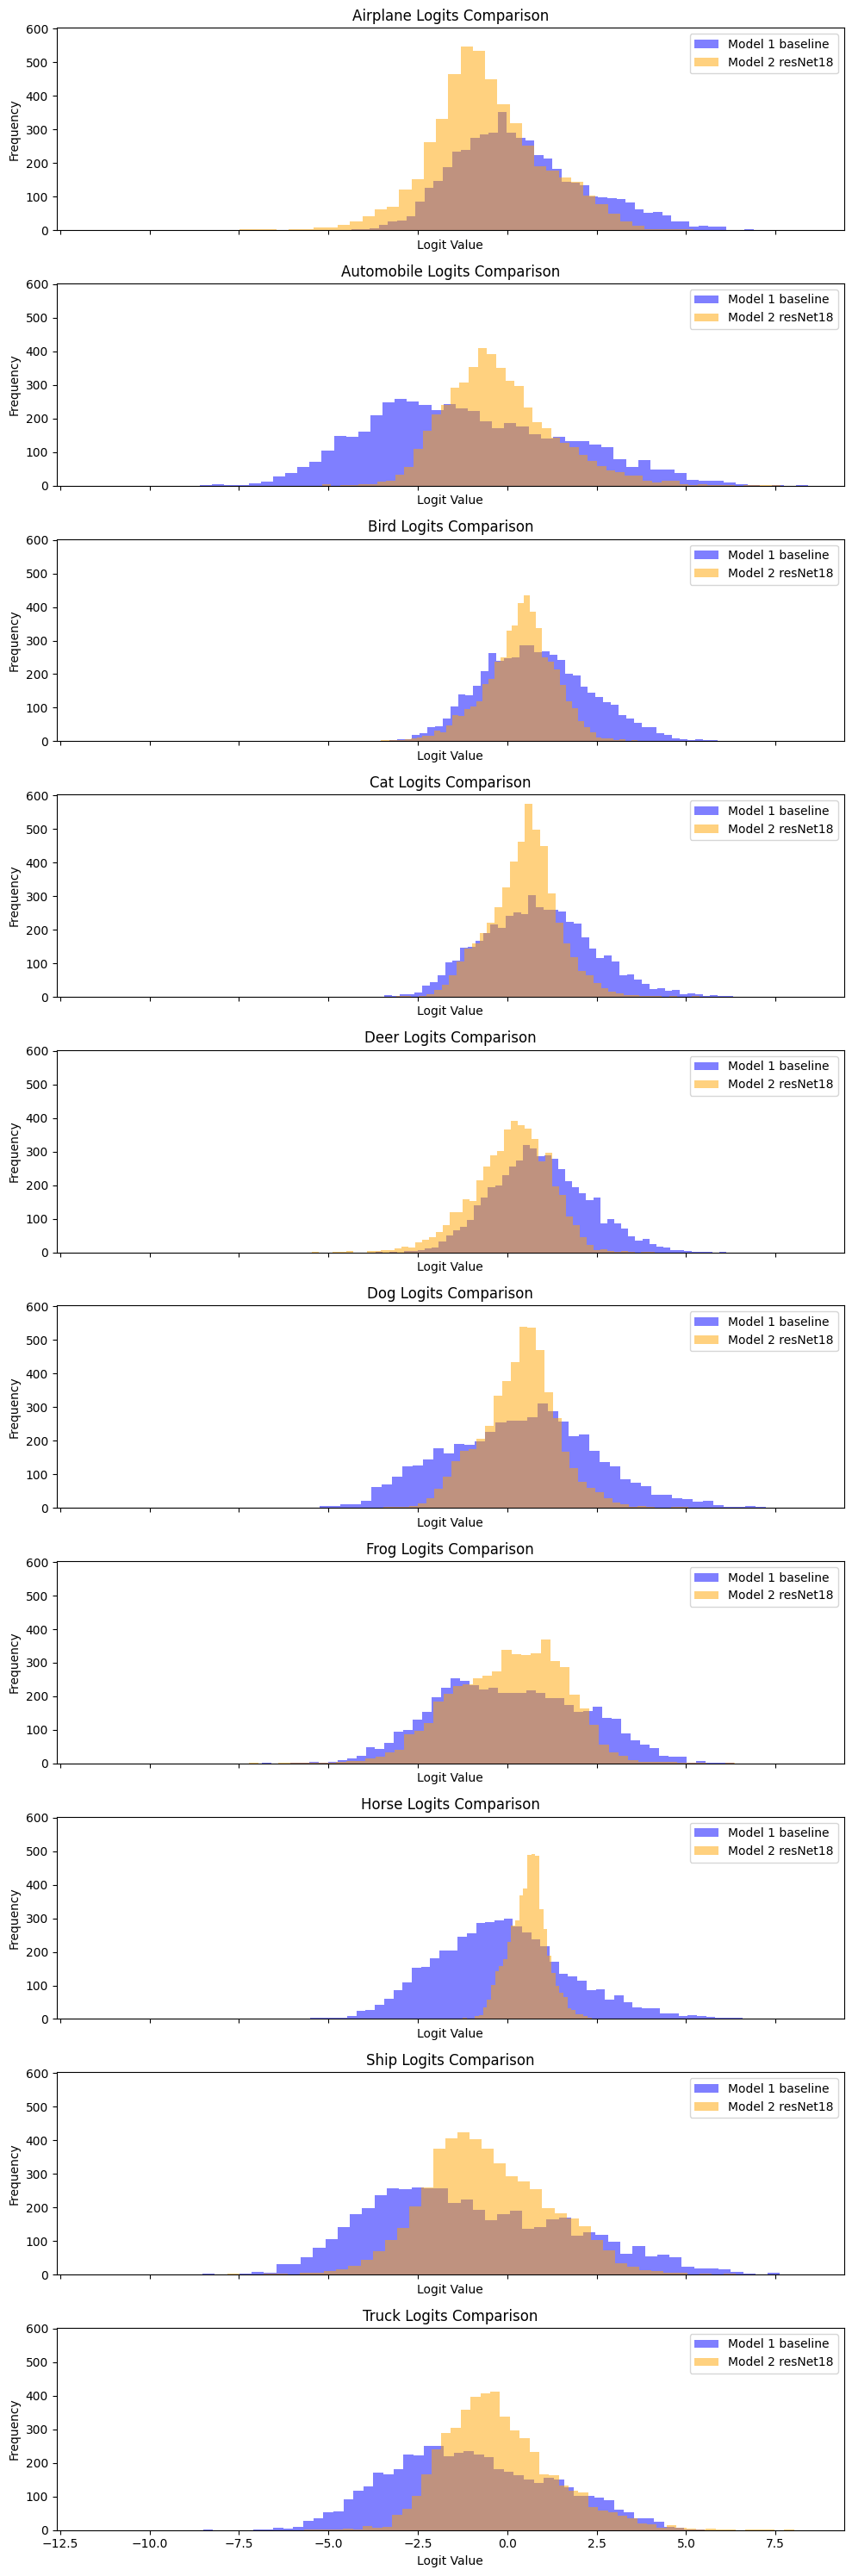

IndexError: invalid index to scalar variable.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode

# CIFAR-10 class labels
cifar10_labels = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

def get_logits_for_visualization(model, data_loader, device, max_examples=5000):
    model.eval()
    model.to(device)
    logits_per_example = []
    example_count = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            logits_per_example.extend(outputs.cpu().numpy())
            example_count += inputs.size(0)

            if example_count >= max_examples:
                break

    return np.array(logits_per_example[:max_examples])

def plot_overlayed_logits_histogram(logits1, logits2, model_name1, model_name2, num_classes=10, num_bins=50):
    fig, axs = plt.subplots(num_classes, 1, figsize=(10, num_classes * 3), sharex=True, sharey=True)

    for i in range(num_classes):
        axs[i].hist(logits1[:, i], bins=num_bins, alpha=0.5, color='blue', label=f'{model_name1}')
        axs[i].hist(logits2[:, i], bins=num_bins, alpha=0.5, color='orange', label=f'{model_name2}')
        axs[i].set_title(f'{cifar10_labels[i]} Logits Comparison')
        axs[i].set_ylabel('Frequency')
        axs[i].legend(loc='upper right')

    for ax in axs:
        ax.set_xlabel('Logit Value')

    plt.tight_layout()
    plt.show()

def calculate_and_print_modes(logits1, logits2, model_name1, model_name2, num_classes=10):
    for i in range(num_classes):
        mode1 = mode(logits1[:, i], axis=None).mode[0]
        mode2 = mode(logits2[:, i], axis=None).mode[0]
        print(f"{cifar10_labels[i]}: {model_name1} Mode = {mode1}, {model_name2} Mode = {mode2}")

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect logits for visualization (first 5000 examples)
logits_model1 = get_logits_for_visualization(model1, test_loader, device, max_examples=5000)
logits_model2 = get_logits_for_visualization(model2, test_loader, device, max_examples=5000)

# Visualize the overlayed logits for each class
plot_overlayed_logits_histogram(logits_model1, logits_model2, "Model 1 baseline", "Model 2 resNet18")

# Calculate and print the modes for comparison
calculate_and_print_modes(logits_model1, logits_model2, "Model 1 baseline", "Model 2 resNet18")


#### confidence

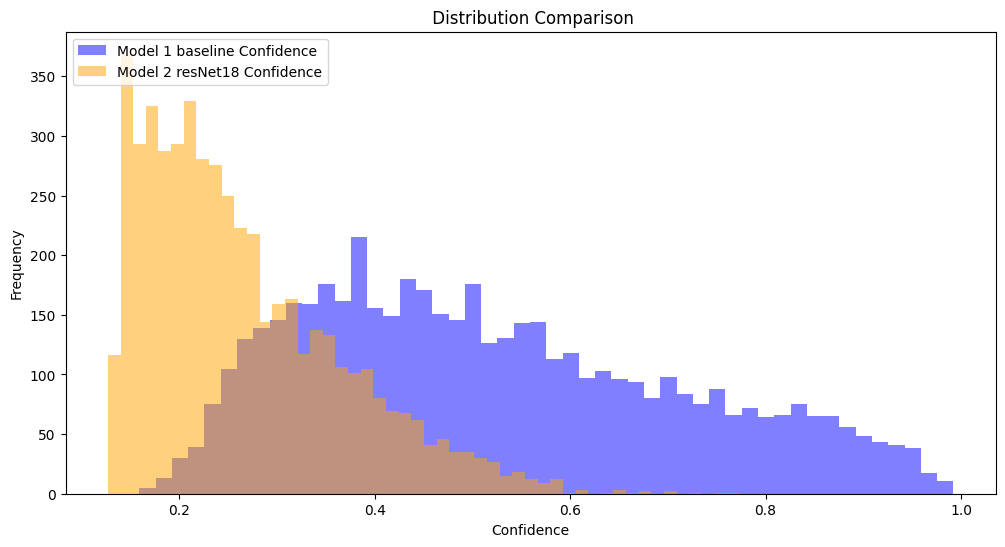

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class labels
cifar10_labels = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

def get_logits_for_visualization(model, data_loader, device, max_examples=5000):
    model.eval()
    model.to(device)
    logits_per_example = []
    example_count = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            logits_per_example.extend(outputs.cpu().numpy())
            example_count += inputs.size(0)

            if example_count >= max_examples:
                break

    return np.array(logits_per_example[:max_examples])

def get_confidence_from_logits(logits):
    softmax_scores = torch.softmax(torch.tensor(logits), dim=1).numpy()
    confidence = np.max(softmax_scores, axis=1)  # Maximum softmax score per example
    return confidence

def plot_confidence_histogram(confidence1, confidence2, model_name1, model_name2, num_bins=50):
    plt.figure(figsize=(12, 6))
    plt.hist(confidence1, bins=num_bins, alpha=0.5, color='blue', label=f'{model_name1} Confidence')
    plt.hist(confidence2, bins=num_bins, alpha=0.5, color='orange', label=f'{model_name2} Confidence')
    plt.title(' Distribution Comparison')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.legend(loc='upper left')
    plt.show()

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect logits for visualization (first 5000 examples)
logits_model1 = get_logits_for_visualization(model1, test_loader, device, max_examples=5000)
logits_model2 = get_logits_for_visualization(model2, test_loader, device, max_examples=5000)

# Calculate confidence for each model
confidence_model1 = get_confidence_from_logits(logits_model1)
confidence_model2 = get_confidence_from_logits(logits_model2)

# Visualize the confidence levels
plot_confidence_histogram(confidence_model1, confidence_model2, "Model 1 baseline", "Model 2 resNet18")


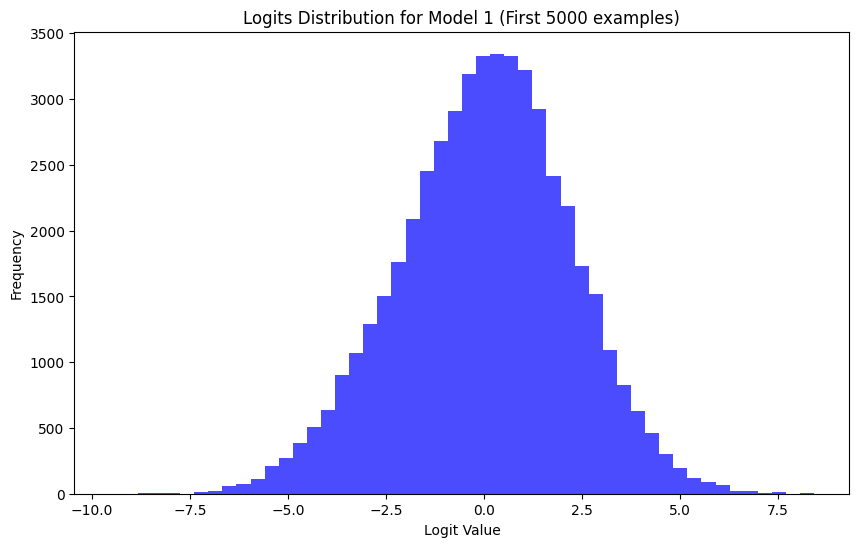

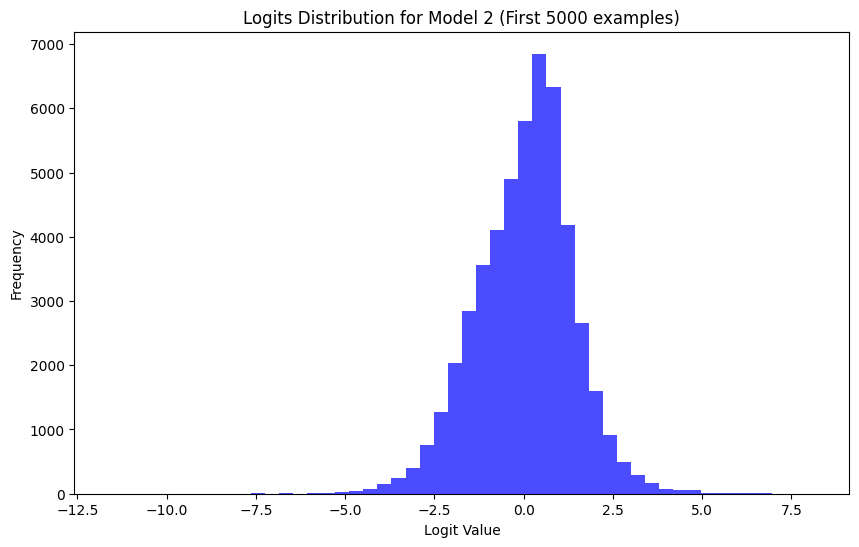

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_logits_for_visualization(model, data_loader, device, max_examples=5000):
    model.eval()
    model.to(device)
    logits_per_example = []
    example_count = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.shape[1] != 10:  # Assuming CIFAR-10 with 10 classes
                raise ValueError(f"Unexpected output shape: {outputs.shape}. Expected (batch_size, 10)")

            logits_per_example.extend(outputs.cpu().numpy())
            example_count += inputs.size(0)

            if example_count >= max_examples:
                break

    return np.array(logits_per_example[:max_examples])

def plot_logits_histogram(logits, model_name, num_bins=50):
    plt.figure(figsize=(10, 6))
    plt.hist(logits.flatten(), bins=num_bins, alpha=0.7, color='blue')
    plt.title(f'Logits Distribution for {model_name} (First 5000 examples)')
    plt.xlabel('Logit Value')
    plt.ylabel('Frequency')
    plt.show()

# Ensure both models and data loader are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect logits for visualization (first 5000 examples)
logits_model1 = get_logits_for_visualization(model1, test_loader, device, max_examples=5000)
logits_model2 = get_logits_for_visualization(model2, test_loader, device, max_examples=5000)

# Visualize the logits
plot_logits_histogram(logits_model1, "Model 1")
plot_logits_histogram(logits_model2, "Model 2")
